In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader as data
import yfinance as yf


In [5]:
start = '2010-01-01'
end = '2019-12-31'
df = yf.download('AAPL', start=start , end=end)
print(df.head())

C:\Users\arlee\AppData\Local\Temp\ipykernel_20788\2441330190.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start=start , end=end)
[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open     Volume
Ticker          AAPL      AAPL      AAPL      AAPL       AAPL
Date                                                         
2010-01-04  6.418384  6.433080  6.369499  6.400989  493729600
2010-01-05  6.429482  6.465771  6.395591  6.436080  601904800
2010-01-06  6.327211  6.454973  6.320613  6.429481  552160000
2010-01-07  6.315515  6.358102  6.269628  6.350604  477131200
2010-01-08  6.357501  6.358101  6.269928  6.307116  447610800


In [6]:
print(df.tail())


Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2019-12-23  68.523346  68.583666  67.647501  67.686106   98572000
2019-12-24  68.588493  68.738093  68.262772  68.689834   48478800
2019-12-26  69.949310  69.966202  68.692247  68.721199   93121200
2019-12-27  69.922783  70.928921  69.517435  70.241274  146266000
2019-12-30  70.337769  70.620069  68.817711  69.840734  144114400


In [7]:
df=df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2010-01-04,6.418384,6.433080,6.369499,6.400989,493729600
1,2010-01-05,6.429482,6.465771,6.395591,6.436080,601904800
2,2010-01-06,6.327211,6.454973,6.320613,6.429481,552160000
3,2010-01-07,6.315515,6.358102,6.269628,6.350604,477131200
4,2010-01-08,6.357501,6.358101,6.269928,6.307116,447610800


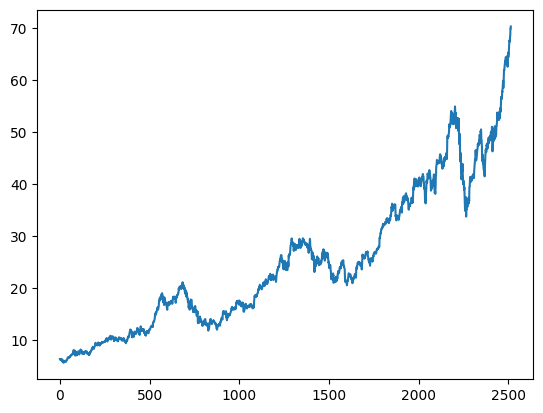

In [8]:
plt.plot(df.Close)

In [9]:
ma100 = df.Close.rolling(100).mean()
ma100

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2510,57.017865
2511,57.214823
2512,57.450983
2513,57.678107


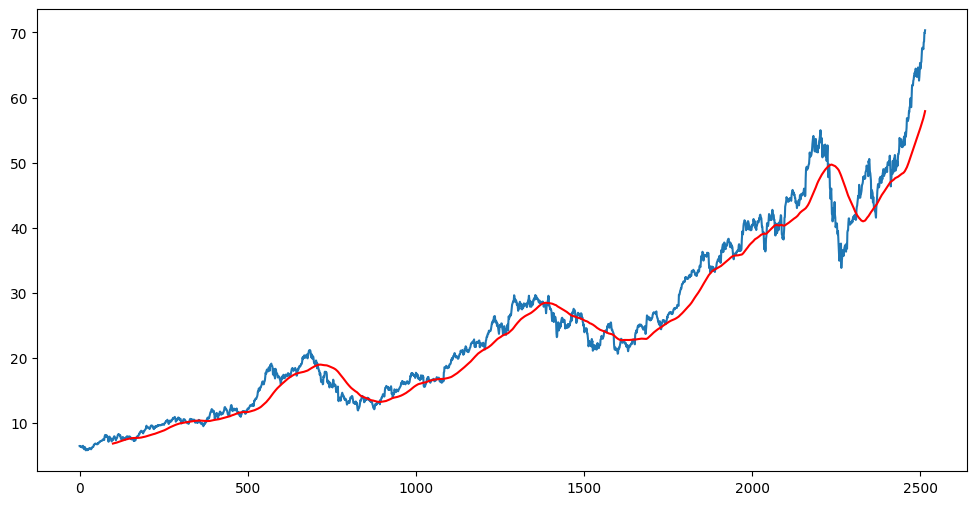

In [10]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100, 'red')

In [11]:
ma200 = df.Close.rolling(200).mean()
ma200

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2510,51.986696
2511,52.113697
2512,52.246548
2513,52.376855


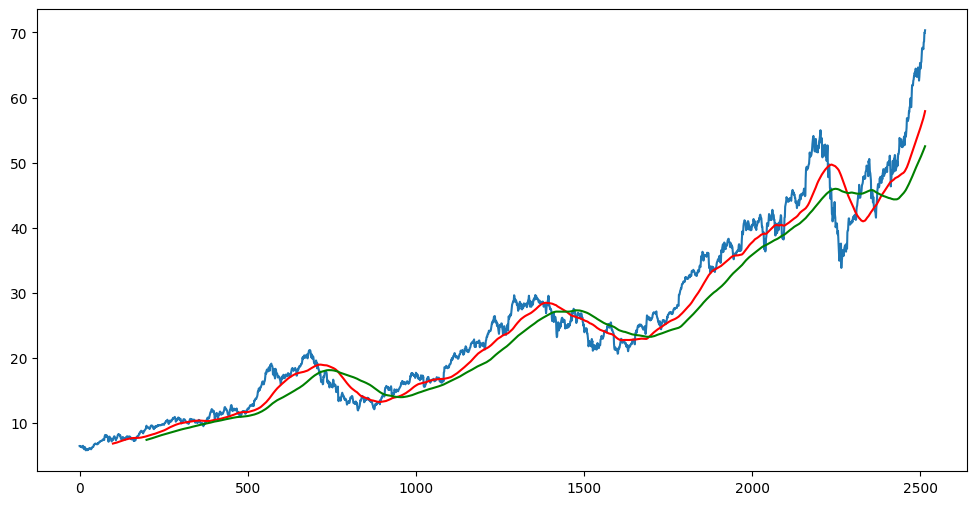

In [12]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100, 'red')
plt.plot(ma200,'green')

In [13]:
df.shape

(2515, 6)

In [14]:
# Splitting Data into Traning and Testing 
data_training=pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing =pd.DataFrame(df['Close'][int(len(df)*0.70): int(len(df))])

print(data_training.shape)
print(data_testing.shape)

(1760, 1)
(755, 1)


In [15]:
data_training.head()


Ticker,AAPL
0,6.418384
1,6.429482
2,6.327211
3,6.315515
4,6.357501


In [16]:
data_testing.head()

Ticker,AAPL
1760,26.904564
1761,26.694818
1762,26.770884
1763,26.740921
1764,26.876902


In [17]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
data_training_array= scaler.fit_transform(data_training)
data_training_array

array([[0.02760002],
       [0.02806508],
       [0.02377926],
       ...,
       [0.88408402],
       [0.89123186],
       [0.88640218]], shape=(1760, 1))

In [18]:
data_training_array.shape

(1760, 1)

In [19]:
x_train=[]
y_train =[]
for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i,0])
x_train, y_train=np.array(x_train),np.array(y_train)

In [20]:
# ML Model
from tensorflow import keras
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [21]:
model=Sequential()
model.add(LSTM(units=50, activation='relu', return_sequences=True, 
               input_shape = (x_train.shape[1],1)))
model.add(Dropout(0.2))


model.add(LSTM(units=60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))


model.add(LSTM(units=80, activation='relu', return_sequences=True))
model.add(Dropout(0.4))


model.add(LSTM(units=120, activation='relu'))
model.add(Dropout(0.5))


model.add(Dense(units=1))

c:\Users\arlee\Stock_market\streamlit_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 27s 284ms/step - loss: 0.0518
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 235ms/step - loss: 0.0121
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 266ms/step - loss: 0.0110
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 273ms/step - loss: 0.0092
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 265ms/step - loss: 0.0097
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 264ms/step - loss: 0.0074
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 260ms/step - loss: 0.0067
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 259ms/step - loss: 0.0079
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 267ms/step - loss: 0.0075
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 262ms/step - loss: 0.0076
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 266ms/step - loss: 0.0064
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 264ms/step - loss: 0.0064
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 158ms/step - loss: 0.0052
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 169ms/step - loss: 0.0061
Epoch 15/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 27

In [24]:
model.save('keras_model.h5')

In [25]:
data_testing.head()

Ticker,AAPL
1760,26.904564
1761,26.694818
1762,26.770884
1763,26.740921
1764,26.876902


In [26]:
past_100_days = data_training.tail(100)

In [27]:
final_df=pd.concat([past_100_days, data_testing], ignore_index=True)

In [28]:
final_df.head()

Ticker,AAPL
0,24.850121
1,24.951017
2,24.765272
3,24.749226
4,24.806551


In [29]:
input_data=scaler.fit_transform(final_df)
input_data

array([[0.02573562],
       [0.02789665],
       [0.02391832],
       [0.02357463],
       [0.02480244],
       [0.0311872 ],
       [0.03069616],
       [0.02991025],
       [0.02922275],
       [0.03059787],
       [0.02642312],
       [0.02809311],
       [0.02406584],
       [0.02180664],
       [0.01871234],
       [0.01812301],
       [0.01409566],
       [0.01458678],
       [0.01768095],
       [0.02259235],
       [0.02244499],
       [0.0256866 ],
       [0.01173809],
       [0.        ],
       [0.01134534],
       [0.02367284],
       [0.04243421],
       [0.06109749],
       [0.05790495],
       [0.05132393],
       [0.05127466],
       [0.05117658],
       [0.05643174],
       [0.04705093],
       [0.04788591],
       [0.04891726],
       [0.05314095],
       [0.04444793],
       [0.04872084],
       [0.04611775],
       [0.04847516],
       [0.04872084],
       [0.05284636],
       [0.05368126],
       [0.06345498],
       [0.06468274],
       [0.06979059],
       [0.068

In [30]:
input_data.shape

(855, 1)

In [31]:
x_test=[]
y_test =[]

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])
    

In [32]:
x_test,y_test=np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(755, 100, 1)
(755,)


In [33]:
# Making Predictions
y_predicted = model.predict(x_test)


24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step


In [34]:
y_predicted.shape

(755, 1)

In [35]:
y_test

array([0.06973814, 0.06524577, 0.06687494, 0.0662332 , 0.06914566,
       0.07556327, 0.08089486, 0.08148722, 0.08464671, 0.08217831,
       0.08114153, 0.08588077, 0.08583138, 0.08479468, 0.08588077,
       0.08627556, 0.0857326 , 0.09516157, 0.09545779, 0.0955071 ,
       0.09392743, 0.09254516, 0.12907589, 0.12798988, 0.13070502,
       0.1366782 , 0.14279951, 0.14531722, 0.15002737, 0.14854003,
       0.15434073, 0.1629183 , 0.16534749, 0.16455422, 0.16638897,
       0.1712475 , 0.17328025, 0.17040468, 0.1710492 , 0.172388  ,
       0.17268533, 0.18656761, 0.18245308, 0.18651835, 0.1843366 ,
       0.18522922, 0.18265105, 0.18106444, 0.18334529, 0.18364253,
       0.18260154, 0.1898897 , 0.19102963, 0.1875595 , 0.19484774,
       0.18681567, 0.19464945, 0.19217006, 0.19078191, 0.19197201,
       0.20644923, 0.20803584, 0.20709371, 0.20575507, 0.20595328,
       0.21125832, 0.20754014, 0.20575507, 0.20416854, 0.20332576,
       0.1956906 , 0.19653338, 0.19281462, 0.19668184, 0.19355

In [36]:
y_predicted

array([[0.13770017],
       [0.13861696],
       [0.1394247 ],
       [0.14009061],
       [0.14060192],
       [0.14096093],
       [0.14119373],
       [0.14134952],
       [0.1414842 ],
       [0.14164722],
       [0.141874  ],
       [0.14217573],
       [0.1425531 ],
       [0.14300357],
       [0.14351363],
       [0.1440634 ],
       [0.14463264],
       [0.14520064],
       [0.14576225],
       [0.1463302 ],
       [0.14691542],
       [0.1475212 ],
       [0.14813966],
       [0.14882037],
       [0.14966342],
       [0.15075387],
       [0.15214251],
       [0.15384777],
       [0.1559072 ],
       [0.1583339 ],
       [0.16111144],
       [0.16420521],
       [0.16758358],
       [0.1711779 ],
       [0.17494603],
       [0.17884354],
       [0.18282588],
       [0.18684237],
       [0.19083379],
       [0.1947067 ],
       [0.1983919 ],
       [0.20183489],
       [0.20502305],
       [0.20795676],
       [0.21065101],
       [0.21312007],
       [0.21537709],
       [0.217

In [37]:
scaler.scale_

array([0.02141822])

In [38]:
scale_factor=1/0.02139747
y_predicted = y_predicted *scale_factor
y_test=y_test *scale_factor

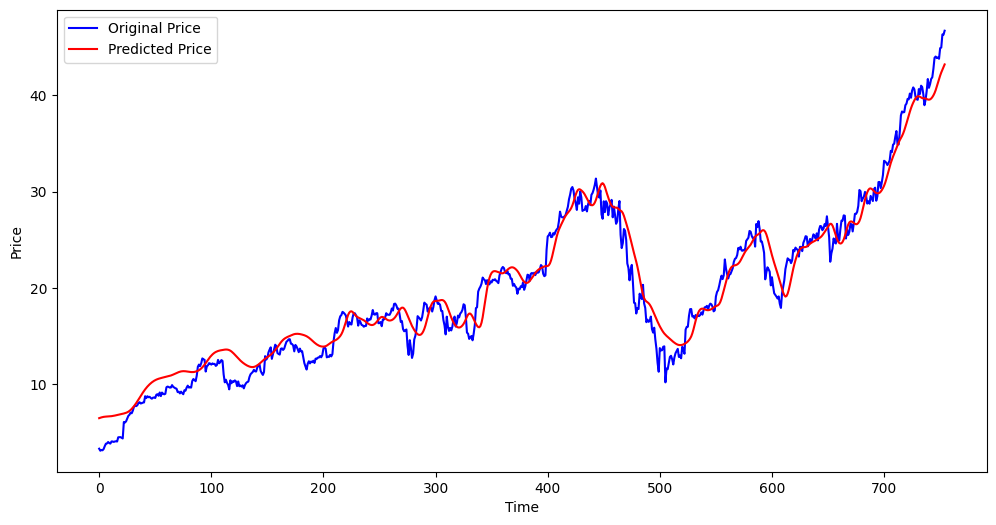

In [39]:
plt.figure(figsize=(12,6))
plt.plot(y_test,'blue', label='Original Price')
plt.plot(y_predicted, 'red', label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()